# Import required packages

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits import mplot3d
%matplotlib inline

# Computing the Lorenz System via numerical methods

The Lorenz System is calculated via Runge-Kutta 4th order method. The function takes an initial condition to start from and the number of steps to compute

In [2]:
# Lorenz differential equations
def lorenz(x, y, z, sigma, rho, beta):
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = (x * y) - (beta * z)
    return([dx, dy, dz])

# Runge-Kutta 4th order. Returns the full array of lorenz steps.
def calc_lorenz(steps, init):
    r = init
    rx = r[0][0]; ry = r[0][1]; rz = r[0][2]

    h = 0.01
    t = 0
    for i in range(1, steps):
        t += h

        k1 = lorenz(rx, ry, rz, sigma, rho, beta)
        k2 = lorenz(rx + h*0.5*k1[0], ry + h*0.5*k1[1], rz + h*0.5*k1[2], sigma, rho, beta)
        k3 = lorenz(rx + h*0.5*k2[0], ry + h*0.5*k2[1], rz + h*0.5*k2[2], sigma, rho, beta)
        k4 = lorenz(rx + h*k3[0], ry + h*k3[1], rz + h*k3[2], sigma, rho, beta)

        rx += h/6*(k1[0] + 2*k2[0] + 2*k3[0] + k4[0])
        ry += h/6*(k1[1] + 2*k2[1] + 2*k3[1] + k4[1])
        rz += h/6*(k1[2] + 2*k2[2] + 2*k3[2] + k4[2])

        r.append([rx, ry, rz])
    
    return np.array(r)

# Dependent functions for ESN implementation

In [3]:
# Standardise a given vector
def standardise(x):
    x = (x - np.mean(x)) / np.std(x)
    return(x)

# Return the spectral radius of a given matrix
def spectral_radius(A):
    eigenvalues = np.linalg.eigvals(A)
    return(max(abs(eigenvalues)))

# Normalises a given matrix
def normalisation(A): 
    s = spectral_radius(A)
    if (s == 0):
        print("Error: spectral radius = 0. Unable to normalise.")
        return
    else:
        return(1/s * A)

# Rescale a matrix to a target spectral radius alpha
def rescale(A, alpha):
    return(alpha * A)

# Generates the input and reservoir weight matrices (with a given seed if applicable)
def generate_DR(gen_seed):
    
    if(gen_seed == 0):
        rng = np.random.default_rng()
    else:
        rng = np.random.default_rng(gen_seed)
        
    W_in = rng.uniform(-0.12, 0.12, size = (N,3))
    W = rescale(normalisation(rng.uniform(-1, 1, size = (N,N))), target_radius)
    
    return(W_in, W)

# Train the W_out matrix in the ESN after a given washout period
def train_esn(U, W, W_in, leak, washout, ridge=1e-3):
    T = U.shape[0]
    N = W.shape[0]
    
    x = np.zeros(N)
    X = []
    Y = []
    
    for n in range(T-1):
        x = (1-leak) * x + leak*np.tanh((W @ x) + (W_in @ U[n]))
        
        if n>= washout:
            z = np.hstack([1, x, U[n]])
            X.append(z)
            Y.append(U[n+1])
            
    X = np.array(X)
    Y = np.array(Y)
    
    I = np.eye(X.shape[1])
    I[0, 0] = 0
    W_out = np.linalg.solve((X.T @ X + ridge * I), X.T @ Y)
    return W_out

# Predict the future state of the dynamical system
def predict_esn(u0, W, W_in, W_out, leak, steps):
    N = W.shape[0]
    x = np.zeros(N)
    u = u0.copy()

    preds = []
    preds.append(u)

    for n in range(steps-1):
        x = (1-leak)*x + leak*np.tanh(W @ x + W_in @ u)
        z = np.hstack([1, x, u])
        u = z @ W_out
        preds.append(u)

    return np.array(preds)

# Tune parameters

### Lorenz parameters

In [4]:
sigma = 10
rho =  28
beta = 8/3

initial_condition = [[0.1,0.1,0.1]] # Initial condition u(0) for lorenz system

### RC parameters

In [5]:
seed = 4 # Set a seed for reproducibility (set seed to 0 for random)

N = 500 # Number of internal reservoir units
leak = 0.6 # Leaky integration parameter
pred_steps = 2000 # Number of steps to predict
target_radius = 0.9 # Target reservoir spectral radius to rescale W_res to

t_listen = 1000 # The washout period
t_train = 10000 # Number of Lorenz system steps to store

rmse_cutoff = 200 # Cutoff point when calculating the RMSE of the predicted data

# Apply ESN

In [6]:
# Generate the dynamic reservoirs for W^in and W^res
W_in, W_res = generate_DR(seed)

# # Compute Lorenz System time series data
input_signal = calc_lorenz(t_train, [[0.1,0.1,0.1]])

# Train W_out output weights
W_out = train_esn(input_signal, W_res, W_in, leak, t_listen)

# Predict the future states
pred_data = predict_esn(input_signal[-1].copy(), W_res, W_in, W_out, leak, pred_steps)

# Prepare data for comparisons in plots

In [7]:
# Calculate the true values for the next steps for comparison
initial_condition = [[input_signal[-1][0], input_signal[-1][1], input_signal[-1][2]]]
true_data = calc_lorenz(pred_steps, initial_condition)

# Setup the prediction range space
pred_range = np.linspace(t_train, t_train + pred_steps, pred_steps)

# Plot input signal u(t)

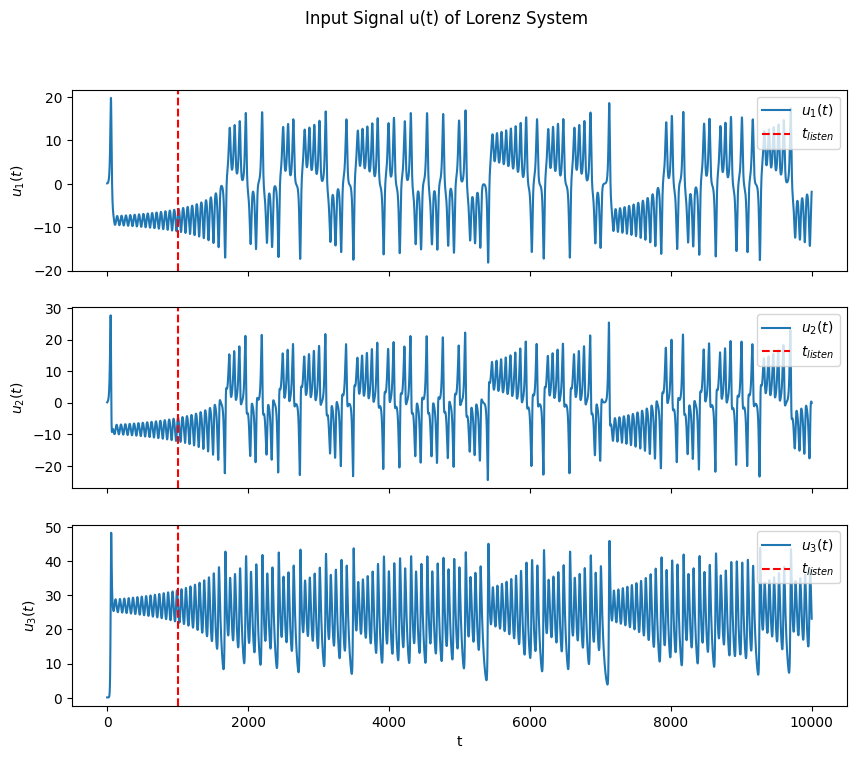

In [8]:
input_range = np.linspace(0, t_train, t_train)

# Plot the input signal
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

labels = [r'$u_1(t)$', r'$u_2(t)$', r'$u_3(t)$']

fig.suptitle("Input Signal u(t) of Lorenz System")


for i in range(0,3):
    axes[i].plot(input_range, input_signal[:,i], label=labels[i])
    axes[i].set_ylabel(labels[i])
    axes[i].axvline(x=(t_listen), color='red', linestyle='--', label=r'$t_{listen}$')
    axes[i].legend(loc='upper right')

plt.xlabel("t")
plt.savefig("lorenz_input_signal.png")
plt.show()

# Plot component-wise true data vs predicted data

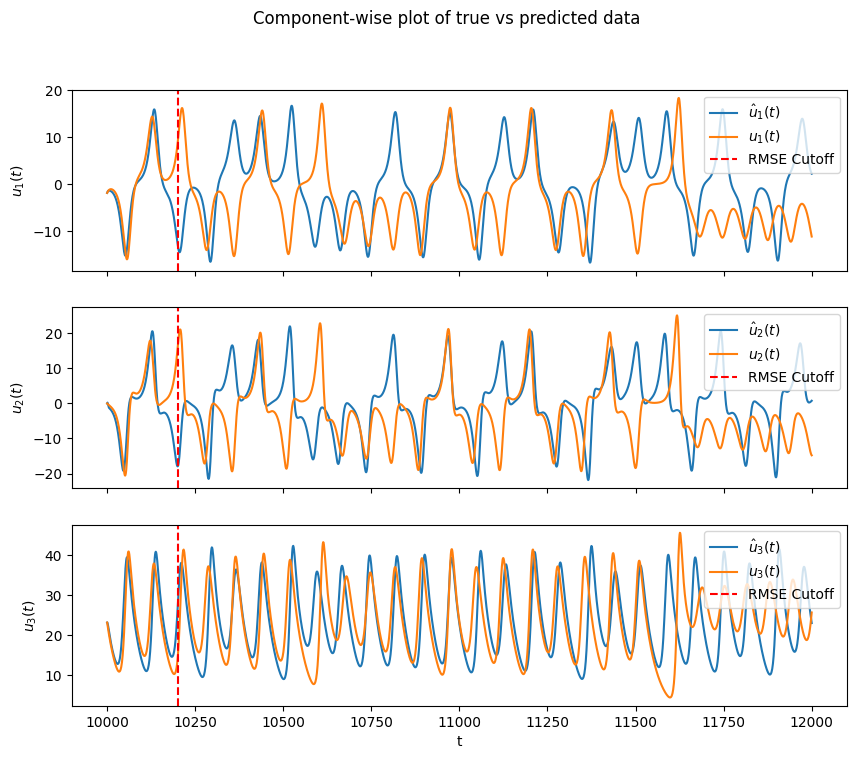

In [9]:
# Setup the prediction range space
pred_range = np.linspace(t_train, t_train + pred_steps, pred_steps)

# Plot the predicted values against true values
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

labels_pred = [r'$\hat{u}_1(t)$', r'$\hat{u}_2(t)$', r'$\hat{u}_3(t)$']

fig.suptitle("Component-wise plot of true vs predicted data")

for i in range(0,3):
    axes[i].plot(pred_range, pred_data[:,i], label=labels_pred[i])
    axes[i].plot(pred_range, true_data[:,i], label=labels[i])
    axes[i].axvline(x=(rmse_cutoff + t_train), color='red', linestyle='--', label="RMSE Cutoff")
    axes[i].set_ylabel(labels[i])
    axes[i].legend(loc='upper right')

plt.xlabel("t")
plt.savefig("lorenz_prediction.png")
plt.show()

# A 3D plot of true data vs predicted data

C:\Users\ronan\AppData\Local\Temp\ipykernel_18808\483330753.py:2: MatplotlibDeprecationWarning: The clean function was deprecated in Matplotlib 3.8 and will be removed two minor releases later. Use none, you no longer need to clean a Grouper instead.
  ax3d.plot3D(true_data[:,0], true_data[:,1], true_data[:,2], label=r'$u(t)$')
C:\Users\ronan\AppData\Local\Temp\ipykernel_18808\483330753.py:3: MatplotlibDeprecationWarning: The clean function was deprecated in Matplotlib 3.8 and will be removed two minor releases later. Use none, you no longer need to clean a Grouper instead.
  ax3d.plot3D(pred_data[:,0], pred_data[:,1], pred_data[:,2], label=r'$\hat{u}(t)$')


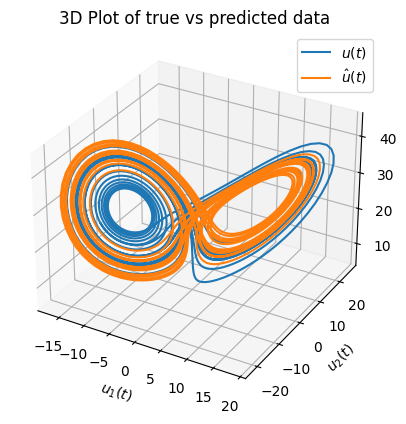

In [10]:
ax3d = plt.axes(projection='3d')
ax3d.plot3D(true_data[:,0], true_data[:,1], true_data[:,2], label=r'$u(t)$')
ax3d.plot3D(pred_data[:,0], pred_data[:,1], pred_data[:,2], label=r'$\hat{u}(t)$')
ax3d.legend(loc="upper right")

plt.title("3D Plot of true vs predicted data")
plt.savefig("lorenz_prediction_3d.png")

ax3d.set_xlabel(r'$u_1(t)$')
ax3d.set_ylabel(r'$u_2(t)$')
ax3d.set_zlabel(r'$u_3(t)$')


plt.show()

# Computing the Root Mean Square Error of true data vs predicted data

In [11]:
rmse = np.sqrt(sum(((true_data[:rmse_cutoff] - pred_data[:rmse_cutoff]) ** 2) / rmse_cutoff))
print(f"Root Mean Square Error:", rmse)

Root Mean Square Error: [4.57865905 7.54930093 4.90696865]


# Plot of standardised residuals until cutoff 

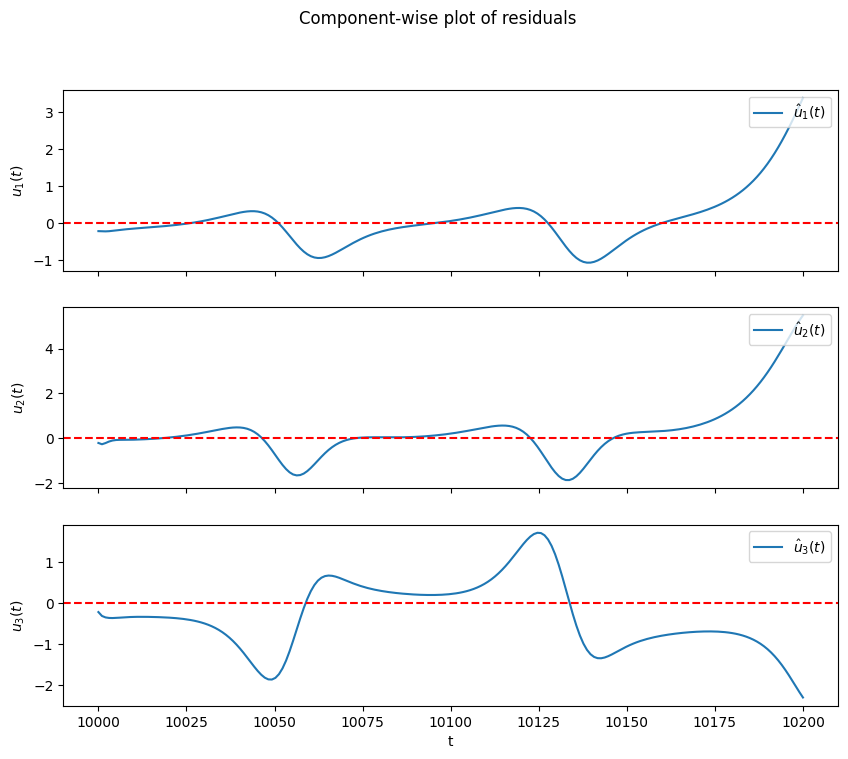

In [12]:
residuals = standardise(true_data[:rmse_cutoff] - pred_data[:rmse_cutoff])

# Setup the prediction range space
residuals_range = np.linspace(t_train, t_train + rmse_cutoff, rmse_cutoff)

# Plot the predicted values against true values
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

labels_pred = [r'$\hat{u}_1(t)$', r'$\hat{u}_2(t)$', r'$\hat{u}_3(t)$']

fig.suptitle("Component-wise plot of residuals")

for i in range(0,3):
    axes[i].plot(residuals_range, residuals[:,i], label=labels_pred[i])
    axes[i].set_ylabel(labels[i])
    axes[i].axhline(y=0, color='red', linestyle='--')
    axes[i].legend(loc='upper right')

plt.xlabel("t")
plt.savefig("lorenz_residuals.png")
plt.show()